Esta definicion se da en la guia del dataset, me parece que esta bueno decirla para que se entienda bien de que estamos habalndo.
___
UCDP define an event as: An incident where armed force was used by an organized actor
against another organized actor, or against civilians, resulting in at least 1 direct death at a
specific location and a specific date”.
___

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../Datasets/ged251-csv/GEDEvent_v25_1.csv")

/tmp/ipykernel_60832/2130334266.py:5: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../Datasets/ged251-csv/GEDEvent_v25_1.csv")


In [2]:
#Check para saber si id es efecitvamente unico
rows, cols = df.shape
"Ok" if df["id"].nunique() - rows == 0 else "No es unico"

'Ok'

In [3]:
# Limpieza de algunas columnas legacy
df = df.drop(columns=[
    'relid',
    'code_status',
    'conflict_dset_id',
    'dyad_dset_id',
    'side_a_dset_id',
    'side_b_dset_id',
    ])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385918 entries, 0 to 385917
Data columns (total 43 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 385918 non-null  int64  
 1   year               385918 non-null  int64  
 2   active_year        385918 non-null  bool   
 3   type_of_violence   385918 non-null  int64  
 4   conflict_new_id    385918 non-null  int64  
 5   conflict_name      385918 non-null  object 
 6   dyad_new_id        385918 non-null  int64  
 7   dyad_name          385918 non-null  object 
 8   side_a_new_id      385918 non-null  int64  
 9   side_a             385918 non-null  object 
 10  side_b_new_id      385918 non-null  int64  
 11  side_b             385918 non-null  object 
 12  number_of_sources  385918 non-null  int64  
 13  source_article     385917 non-null  object 
 14  source_office      288005 non-null  object 
 15  source_date        288005 non-null  object 
 16  so

___
Me parece que puede ser mas explicativo agrupar las columnas en rasgos comunes, ya que mostrar +40 es complicado.
Propongo hacer la siguiente agrupacion:
- ID: Contiene identificador unico del evento
    - id
- Temporales: Contienen info relativa al tiempo del conflicto
    - year
    - active_year
    - date_prec
    - date_start
    - date_end
- Implicados: Contiene info de las partes implicadas en el evento
    - dyad_new_id
    - dyad_name
    - side_a_new_id
    - side_b_new_id
    - side_a
    - side_b
    - gwnoa
    - gwnob
- Fuentes: Contienen info de las fuentes de informacion
    - number_of_sources
    - source_article
    - source_office
    - source_date
    - source_headline
    - source_original
- Espaciales: Contienen info relativa al lugar de los hechos
    - where_prec
    - where_coordinates
    - where_description
    - adm_1
    - adm_2
    - latitude
    - longitude
    - geom_wkt
    - priogrid_grid
    - country
    - country_id
    - region
- Conflicto: Contiente info del conflicto al que el evento pertenece
    - type_of_violence
    - conflict_new_id
    - conflict_name
    - event_clarity
- Muertes: Contiene info de las muertes referidas al evento:
    - deaths_a
    - deaths_b
    - deaths_civilians
    - deaths_unknown
    - best
    - high
    - low

___

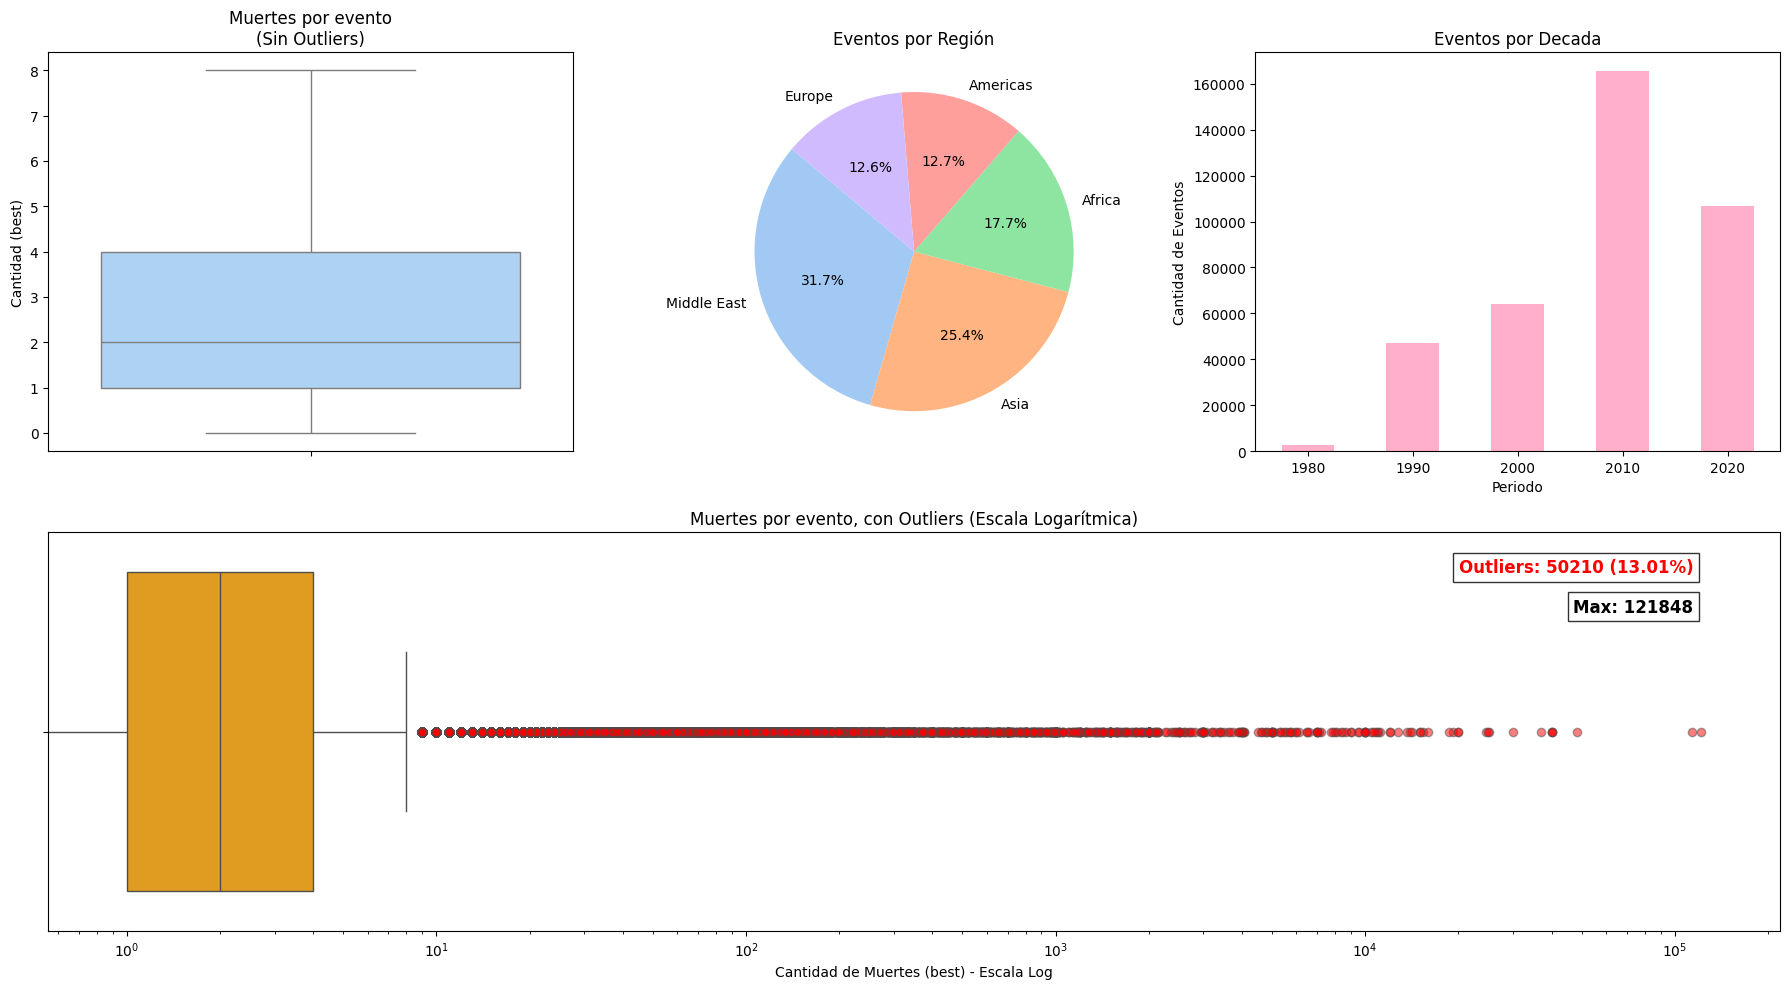

In [4]:
# Algunos graficos basicos con info macro del dataset

# Config de la figura: 2 filas, 3 columnas
fig = plt.figure(figsize=(18, 10))

#---Layout---

# Fila superior: 3 graficos
ax1 = plt.subplot2grid((2, 3), (0, 0)) 
ax2 = plt.subplot2grid((2, 3), (0, 1)) 
ax3 = plt.subplot2grid((2, 3), (0, 2)) 

# Fila inferior: 1 grafico para las 3 columnas
ax4 = plt.subplot2grid((2, 3), (1, 0), colspan=3) 

#---Graficos---

# Muertes por eventos sin outliers
sns.boxplot(data=df, y='best', ax=ax1, color='#a2d2ff', showfliers=False)
ax1.set_title('Muertes por evento\n(Sin Outliers)')
ax1.set_ylabel('Cantidad (best)')

# Eventos por region

region_counts = df['region'].value_counts()
ax2.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'))
ax2.set_title('Eventos por Región')

# Eventos por decada
df['decada'] = (df['year'] // 10) * 10
decade_counts = df.groupby('decada').size()
decade_counts.plot(kind='bar', ax=ax3, color='#ffafcc')
ax3.set_title('Eventos por Decada')
ax3.set_xlabel('Periodo')
ax3.set_ylabel('Cantidad de Eventos')
ax3.tick_params(axis='x', rotation=0)

# Muertes con outliers

Q1 = df['best'].quantile(0.25)
Q3 = df['best'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
outliers = df[df['best'] > limite_superior]
num_outliers = len(outliers)
max_val = df['best'].max()

ax = sns.boxplot(data=df, x='best', color='orange', flierprops={'markerfacecolor':'red', 'alpha':0.5})
ax.set_xscale('log')
plt.title('Muertes por evento, con Outliers (Escala Logarítmica)')
plt.xlabel('Cantidad de Muertes (best) - Escala Log')
ax.text(0.95, 0.90, f'Outliers: {num_outliers} ({((num_outliers/rows)*100):.2f}%)', transform=ax.transAxes, 
         ha='right', fontsize=12, fontweight='bold', color='red', 
         bbox=dict(facecolor='white', alpha=0.8))

ax.text(0.95, 0.80, f'Max: {max_val}', transform=ax.transAxes, 
         ha='right', fontsize=12, fontweight='bold', 
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


In [5]:
fila_maxima = df.loc[df['best'].idxmax()]
print(fila_maxima)

id                                                              463137
year                                                              2022
active_year                                                       True
type_of_violence                                                     1
conflict_new_id                                                    267
conflict_name                                     Ethiopia: Government
dyad_new_id                                                        555
dyad_name                                Government of Ethiopia - TPLF
side_a_new_id                                                       97
side_a                                          Government of Ethiopia
side_b_new_id                                                      410
side_b                                                            TPLF
number_of_sources                                                    2
source_article       "Responsible Statecraft,2022-11-16,Facing fami...
source

___
El evento mas letal corresponde a un conflicto entre el gobierno de Etipia y el Frente de liberacion del Pueblo de Trigay, en el ano 2022
___

In [6]:
#Estadisticos basicos 
df.describe()

,id,year,type_of_violence,conflict_new_id,dyad_new_id,side_a_new_id,side_b_new_id,number_of_sources,where_prec,latitude,...,date_prec,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnob,decada
count,385918.000000,385918.000000,385918.000000,385918.000000,385918.000000,385918.000000,385918.000000,385918.000000,385918.000000,385918.000000,...,385918.000000,385918.000000,385918.000000,385918.000000,385918.000000,385918.000000,385918.000000,385918.000000,30256.000000,385918.000000
mean,290595.568434,2012.488513,1.451370,3893.462945,6993.735926,633.188048,1752.297999,0.821799,2.049314,26.094948,...,1.223301,2.470660,2.245581,3.819710,1.717893,10.253844,15.117004,8.537456,389.519963,2008.467654
std,158412.337429,9.408420,0.746014,5774.828401,6475.379382,1705.337821,2396.029834,1.648170,1.261082,16.048457,...,0.646853,254.720238,53.764628,178.402817,99.617277,347.680699,426.859964,313.655348,85.849904,9.835705
min,2.000000,1989.000000,1.000000,205.000000,406.000000,3.000000,1.000000,-1.000000,1.000000,-37.813611,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1980.000000
25%,162928.250000,2007.000000,1.000000,299.000000,781.000000,109.000000,208.000000,-1.000000,1.000000,13.356770,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,369.000000,2000.000000
50%,293210.500000,2014.000000,1.000000,386.000000,5226.000000,118.000000,338.000000,1.000000,2.000000,33.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000,369.000000,2010.000000
75%,422042.750000,2020.000000,2.000000,4979.000000,14117.000000,154.000000,4456.000000,1.000000,3.000000,35.784268,...,1.000000,0.000000,1.000000,1.000000,0.000000,4.000000,5.000000,4.000000,369.000000,2020.000000
max,572006.000000,2024.000000,3.000000,16527.000000,18362.000000,9363.000000,9392.000000,361.000000,7.000000,68.979170,...,5.000000,121848.000000,19874.000000,40000.000000,48183.000000,121848.000000,121848.000000,121848.000000,800.000000,2020.000000
